# LR & XGB for PhysioNet 2012 Challenge

This Google Colab notebook implements LR & XGB for the PhysioNet 2012 Challenge of predicting in-hospital mortality.

In [ ]:
# import libraries
import os
import torch
import numpy as np
import pandas as pd

from tqdm import tqdm
from torch import nn, optim
from sklearn.metrics import roc_auc_score, average_precision_score


In [ ]:
# mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# define paths to PhysioNet 2012 data in Google Drive
google_drive_folder = '/content/drive/MyDrive/physionet2012/'
set_a_directory = f"{google_drive_folder}/set-a"
set_b_directory = f"{google_drive_folder}/set-b"
outcomes_a_file = f"{set_a_directory}/Outcomes-a.txt"
outcomes_b_file = f"{set_b_directory}/Outcomes-b.txt"
set_c_directory = f"{google_drive_folder}/set-c"
outcomes_c_file = f"{set_c_directory}/Outcomes-c.txt"

In [ ]:
###############################################################################
# Helper Functions
###############################################################################

def load_outcomes(outcomes_path):
    """
    reads the outcomes file into a pandas dataframe.
    columns: [recordid, saps-i, sofa, length_of_stay, survival, in-hospital_death]
    returns a dataframe indexed by recordid.
    """
    df_out = pd.read_csv(outcomes_path)
    df_out.set_index("RecordID", inplace=True)
    return df_out

def time_to_hours(time_str):
    """
    convert 'hh:mm' to a float representing hours from icu admission.
    e.g. '01:06' -> 1.1 hours approximately
    """
    hh, mm = time_str.split(':')
    return int(hh) + int(mm)/60.0

def load_patient_data(file_path, max_hours=48):
    """
    load a single patient file into a dataframe.
    - restricts data to the first 'max_hours' hours.
    - returns columns: [hour, parameter, value].
    """
    df = pd.read_csv(file_path)
    # convert times to numeric hour floats
    df['Hour'] = df['Time'].apply(time_to_hours)
    # filter out any measurements after 'max_hours'
    df = df[df['Hour'] <= max_hours].copy()
    df.drop(columns=['Time'], inplace=True)
    return df.reset_index(drop=True)

def hourly_resample_and_fill(df_patient, max_hours=48):
    """
    pivot raw dataframe to shape [0..(max_hours-1) x parameters].
    for each hourint, if multiple measurements exist, take the last observed.
    then forward-fill across missing hours.
    """
    # convert hour to integer bin
    df_patient['HourInt'] = df_patient['Hour'].astype(int)
    # sort by actual hour and keep last measurement of each parameter in each hour
    df_patient = df_patient.sort_values('Hour', ascending=True)
    df_patient = df_patient.drop_duplicates(subset=['HourInt','Parameter'], keep='last')

    # pivot: rows = hourint (0..47), cols = parameter
    df_pivot = df_patient.pivot(index='HourInt', columns='Parameter', values='Value')

    # reindex to ensure we have exactly 0..(max_hours-1)
    df_pivot = df_pivot.reindex(index=range(max_hours), copy=False)

    # forward fill down the rows
    df_pivot = df_pivot.ffill()

    return df_pivot

def aggregate_hourly_features(df_hourly):
    """
    produce a single row of aggregated features, e.g. 'last', 'mean', 'min', 'max', 'count' for each param.
    returns a series with e.g. param_last, param_mean, param_min, param_max, param_count.
    """
    agg_features = {}

    for col in df_hourly.columns:
        series = df_hourly[col]
        # basic aggregate stats
        agg_features[f"{col}_last"] = series.iloc[-1]
        agg_features[f"{col}_mean"] = series.mean()
        agg_features[f"{col}_min"]  = series.min()
        agg_features[f"{col}_max"]  = series.max()
        agg_features[f"{col}_count"] = series.count()

    return pd.Series(agg_features, dtype=float)

def build_dataset(raw_folder, outcomes_path, max_hours=48):
    """
    for each recordid in outcomes_path, parse the raw data file,
    then produce a single row of aggregated features. merge with the 'in-hospital_death' label.
    returns a dataframe with one row per patient (indexed by recordid).
    """
    # load the outcomes for that set
    df_outcomes = load_outcomes(outcomes_path)

    rows = []
    # loop through all recordids in the outcomes file
    for record_id in tqdm(df_outcomes.index, desc=f"building dataset from {os.path.basename(raw_folder)}"):
        patient_file = os.path.join(raw_folder, f"{record_id}.txt")

        # if the file doesn't exist or is empty, skip
        if not os.path.isfile(patient_file):
            row_agg = pd.Series(dtype=float)
        else:
            # load and process that patient's data
            df_patient = load_patient_data(patient_file, max_hours=max_hours)
            df_hourly = hourly_resample_and_fill(df_patient, max_hours=max_hours)
            row_agg = aggregate_hourly_features(df_hourly)

        # add outcome label
        in_hosp_death = df_outcomes.loc[record_id, 'In-hospital_death']
        row_agg['InHospitalDeath'] = in_hosp_death
        row_agg['RecordID'] = record_id
        rows.append(row_agg)

    # combine everything into one dataframe
    df_agg = pd.DataFrame(rows)
    df_agg.set_index('RecordID', inplace=True)

    return df_agg

In [ ]:
###############################################################################
# 2) Build Train & Test Sets
###############################################################################

print("building training set from set a...")
df_train = build_dataset(set_a_directory, outcomes_a_file, max_hours=48)

print("\nbuilding test/validation set from set b...")
df_test = build_dataset(set_b_directory, outcomes_b_file, max_hours=48)

print("\nbuilding final evaluation set from set c...")
df_final = build_dataset(set_c_directory, outcomes_c_file, max_hours=48)

# Identify columns used as features
feature_cols = [c for c in df_train.columns if c != 'InHospitalDeath']

# Make sure we align the columns in train/test/final sets
common_features = sorted(list(set(feature_cols).intersection(df_test.columns).intersection(df_final.columns)))
X_train = df_train[common_features].fillna(0).values
y_train = df_train['InHospitalDeath'].values

X_test = df_test[common_features].fillna(0).values
y_test = df_test['InHospitalDeath'].values

X_final = df_final[common_features].fillna(0).values
y_final = df_final['InHospitalDeath'].values

Building training set from set A...


Building dataset from set-a: 100%|██████████| 4000/4000 [59:58<00:00,  1.11it/s]



Building test/validation set from set B...


Building dataset from set-b: 100%|██████████| 4000/4000 [56:10<00:00,  1.19it/s]



Building final evaluation set from set C...


Building dataset from set-c: 100%|██████████| 4000/4000 [50:58<00:00,  1.31it/s]


In [ ]:
###############################################################################
# Save/Load df_train and df_test
###############################################################################
import pickle

# define a path to save the pickled dataframes
save_path_train = os.path.join(google_drive_folder, "df_train.pkl")
save_path_test = os.path.join(google_drive_folder, "df_test.pkl")
save_path_final = os.path.join(google_drive_folder, "df_final.pkl")

# save dataframes
df_train.to_pickle(save_path_train)
df_test.to_pickle(save_path_test)
df_final.to_pickle(save_path_final)

print(f"\ndataframes saved to:\n  {save_path_train}\n  {save_path_test}\n  {save_path_final}")


Dataframes saved to:
  /content/drive/MyDrive/physionet2012/df_train.pkl
  /content/drive/MyDrive/physionet2012/df_test.pkl
  /content/drive/MyDrive/physionet2012/df_final.pkl


In [ ]:
###############################################################################
# 3) Logistic Regression Baseline (with Threshold Sweep)
###############################################################################
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score
)
import numpy as np

print("\nTraining Logistic Regression (without class weights)...")
# removed class_weight='balanced'
logreg = LogisticRegression(max_iter=50000, random_state=42, solver='newton-cg')
logreg.fit(X_train, y_train)

# predict probabilities - needed for threshold sweep
y_prob = logreg.predict_proba(X_test)[:, 1]

# --- Threshold Sweep ---
print("Finding optimal threshold based on F1 score...")
thresholds = np.arange(0.01, 1.0, 0.01) # define thresholds to check
f1_scores = []

for thresh in thresholds:
    # apply threshold to probabilities to get predictions
    y_pred_thresh = (y_prob >= thresh).astype(int)
    # calculate F1 score for this threshold
    f1_scores.append(f1_score(y_test, y_pred_thresh))

# find the best threshold
best_threshold_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_idx]
best_f1 = f1_scores[best_threshold_idx]
print(f"Optimal threshold found: {best_threshold:.2f} (yields F1 = {best_f1:.4f})")


y_pred_best_threshold = (y_prob >= best_threshold).astype(int)


Training Logistic Regression (without class weights)...


/usr/local/lib/python3.11/dist-packages/scipy/optimize/_linesearch.py:312: LineSearchWarning: The line search algorithm did not converge
  alpha_star, phi_star, old_fval, derphi_star = scalar_search_wolfe2(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/optimize.py:100: LineSearchWarning: The line search algorithm did not converge
  ret = line_search_wolfe2(


Finding optimal threshold based on F1 score...
Optimal threshold found: 0.25 (yields F1 = 0.5113)


In [ ]:
# Evaluate on Set C (Final)
y_prob_c = logreg.predict_proba(X_final)[:, 1]
y_pred_best_threshold_c = (y_prob_c >= best_threshold).astype(int)

acc_c = accuracy_score(y_final, y_pred_best_threshold_c)
auc_c = roc_auc_score(y_final, y_prob_c)
auprc_c = average_precision_score(y_final, y_prob_c)
precision_c = precision_score(y_final, y_pred_best_threshold_c)
recall_c = recall_score(y_final, y_pred_best_threshold_c)
f1_c = f1_score(y_final, y_pred_best_threshold_c)

print(f"\n[Logistic Regression w/ Optimal Threshold ({best_threshold:.2f}) on set C (FINAL)]")
print(f"Accuracy   = {acc_c:.4f}")
print(f"AUC        = {auc_c:.4f}")
print(f"AUPRC      = {auprc_c:.4f}")
print(f"Precision  = {precision_c:.4f}")
print(f"Recall     = {recall_c:.4f}")
print(f"F1         = {f1_c:.4f}")



[Logistic Regression w/ Optimal Threshold (0.25) on set C (FINAL)]
Accuracy   = 0.8253
AUC        = 0.8419
AUPRC      = 0.5049
Precision  = 0.4329
Recall     = 0.6291
F1         = 0.5129


In [ ]:
###############################################################################
# 4) XGBoost Baseline
###############################################################################
!pip install xgboost
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score
)



print("\nTraining XGBoost...")
xgb_clf = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
)
xgb_clf.fit(X_train, y_train)



Training XGBoost...


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:52:25] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [ ]:
# Evaluate on Set C (Final)
y_pred_xgb_c = xgb_clf.predict(X_final)
y_prob_xgb_c = xgb_clf.predict_proba(X_final)[:, 1]

acc_xgb_c = accuracy_score(y_final, y_pred_xgb_c)
auc_xgb_c = roc_auc_score(y_final, y_prob_xgb_c)
auprc_xgb_c = average_precision_score(y_final, y_prob_xgb_c)
precision_xgb_c = precision_score(y_final, y_pred_xgb_c)
recall_xgb_c = recall_score(y_final, y_pred_xgb_c)
f1_xgb_c = f1_score(y_final, y_pred_xgb_c)

print(f"\n[XGBoost on set C (FINAL)] Accuracy   = {acc_xgb_c:.4f}")
print(f"[XGBoost on set C (FINAL)] AUC        = {auc_xgb_c:.4f}")
print(f"[XGBoost on set C (FINAL)] AUPRC      = {auprc_xgb_c:.4f}")
print(f"[XGBoost on set C (FINAL)] Precision  = {precision_xgb_c:.4f}")
print(f"[XGBoost on set C (FINAL)] Recall     = {recall_xgb_c:.4f}")
print(f"[XGBoost on set C (FINAL)] F1         = {f1_xgb_c:.4f}")



[XGBoost on set C (FINAL)] Accuracy   = 0.8702
[XGBoost on set C (FINAL)] AUC        = 0.8649
[XGBoost on set C (FINAL)] AUPRC      = 0.5444
[XGBoost on set C (FINAL)] Precision  = 0.6375
[XGBoost on set C (FINAL)] Recall     = 0.2615
[XGBoost on set C (FINAL)] F1         = 0.3709


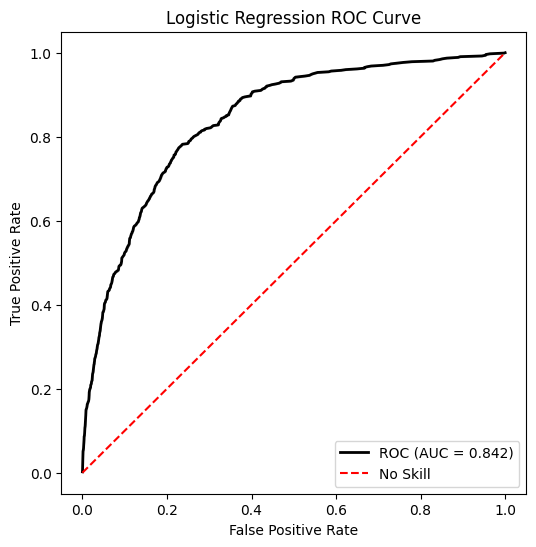

In [ ]:
# =====================================================
# ROC and Calibration Plots for Logistic Regression & XGBoost
# =====================================================
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score
from sklearn.calibration import calibration_curve

# ----------------------------------------
# 1) ROC Curve: Logistic Regression
# ----------------------------------------
fpr_lr_c, tpr_lr_c, _ = roc_curve(y_final, y_prob_c)
roc_auc_lr_c = auc(fpr_lr_c, tpr_lr_c)

plt.figure(figsize=(6, 6))
sns.lineplot(x=fpr_lr_c, y=tpr_lr_c, color='black', linewidth=2,
             label=f'ROC (AUC = {roc_auc_lr_c:.3f})')
plt.plot([0, 1], [0, 1], 'r--', label='No Skill')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression ROC Curve')
plt.legend(loc='lower right')
plt.show()


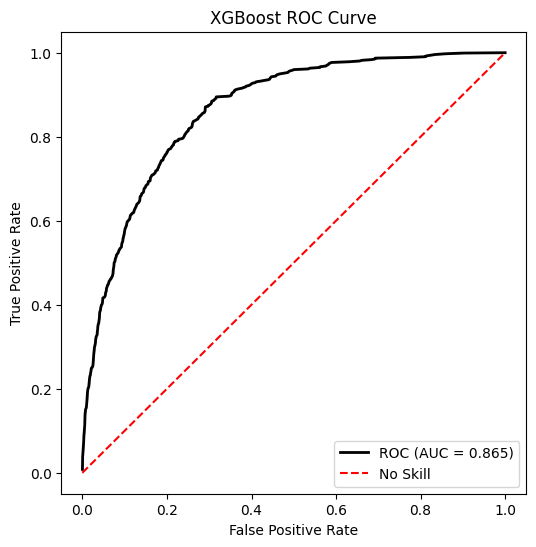

In [ ]:
# ----------------------------------------
# 2) ROC Curve: XGBoost
# ----------------------------------------
fpr_xgb_c, tpr_xgb_c, _ = roc_curve(y_final, y_prob_xgb_c)
roc_auc_xgb_c = auc(fpr_xgb_c, tpr_xgb_c)

plt.figure(figsize=(6, 6))
sns.lineplot(x=fpr_xgb_c, y=tpr_xgb_c, color='black', linewidth=2,
             label=f'ROC (AUC = {roc_auc_xgb_c:.3f})')
plt.plot([0, 1], [0, 1], 'r--', label='No Skill')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost ROC Curve')
plt.legend(loc='lower right')
plt.show()

<ipython-input-17-4fcb9d79d359>:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_lr_c.groupby("bin")


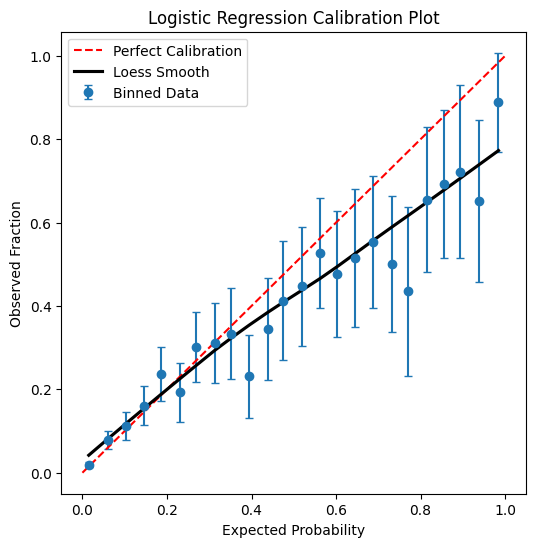

In [ ]:

# ----------------------------------------
# 3) Calibration Plot: Logistic Regression
# ----------------------------------------
num_cuts = 24
df_lr_c = pd.DataFrame({"prob": y_prob_c, "label": y_final})
df_lr_c["bin"] = pd.cut(df_lr_c["prob"], bins=24, include_lowest=True)
grouped_lr_c = (
    df_lr_c.groupby("bin")
    .agg(
        observed=("label", "mean"),
        expected=("prob", "mean"),
        n=("label", "count")
    )
    .reset_index()
)
grouped_lr_c["se"] = np.sqrt(grouped_lr_c["observed"] * (1 - grouped_lr_c["observed"]) / grouped_lr_c["n"])

plt.figure(figsize=(6, 6))
plt.errorbar(
    x=grouped_lr_c["expected"],
    y=grouped_lr_c["observed"],
    yerr=1.96 * grouped_lr_c["se"],
    fmt="o",
    capsize=3,
    label="Binned Data"
)
plt.plot([0, 1], [0, 1], "r--", label="Perfect Calibration")
sns.regplot(
    x="expected",
    y="observed",
    data=grouped_lr_c,
    scatter=False,
    lowess=True,
    color="black",
    label="Loess Smooth"
)
plt.xlabel("Expected Probability")
plt.ylabel("Observed Fraction")
plt.title("Logistic Regression Calibration Plot")
plt.legend(loc="best")
plt.show()



<ipython-input-18-bb1b6ec8d16b>:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_xgb_c.groupby("bin")


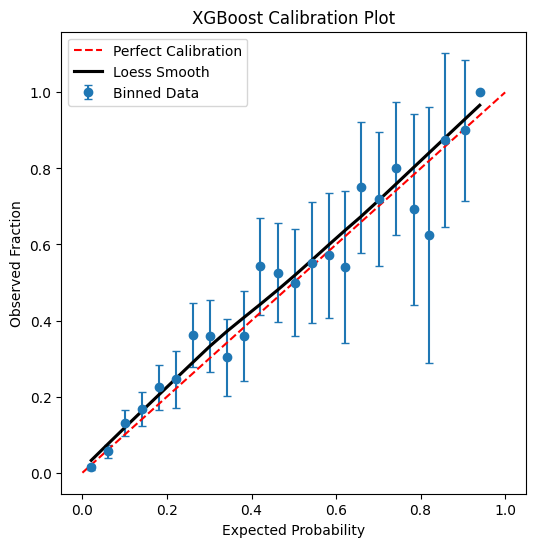

In [ ]:

# ----------------------------------------
# 4) Calibration Plot: XGBoost
# ----------------------------------------
df_xgb_c = pd.DataFrame({"prob": y_prob_xgb_c, "label": y_final})
df_xgb_c["bin"] = pd.cut(df_xgb_c["prob"], bins=24, include_lowest=True)
grouped_xgb_c = (
    df_xgb_c.groupby("bin")
    .agg(
        observed=("label", "mean"),
        expected=("prob", "mean"),
        n=("label", "count")
    )
    .reset_index()
)
grouped_xgb_c["se"] = np.sqrt(grouped_xgb_c["observed"] * (1 - grouped_xgb_c["observed"]) / grouped_xgb_c["n"])

plt.figure(figsize=(6, 6))
plt.errorbar(
    x=grouped_xgb_c["expected"],
    y=grouped_xgb_c["observed"],
    yerr=1.96 * grouped_xgb_c["se"],
    fmt="o",
    capsize=3,
    label="Binned Data"
)
plt.plot([0, 1], [0, 1], "r--", label="Perfect Calibration")
sns.regplot(
    x="expected",
    y="observed",
    data=grouped_xgb_c,
    scatter=False,
    lowess=True,
    color="black",
    label="Loess Smooth"
)
plt.xlabel("Expected Probability")
plt.ylabel("Observed Fraction")
plt.title("XGBoost Calibration Plot")
plt.legend(loc="best")
plt.show()
